In [248]:
# Cell 0 — Setup: load RAD / AQ2 / MWPM / ideal stats and define IPdC-slowdown helpers.
#
# IPdC (instructions per decoding cycle) is the throughput metric -- higher is
# better. We compare RAD, the AQ2-only decoder, and the MWPM-only decoder
# against the ideal decoder.
# Only the shared parser and house color scheme are reused from other notebooks.
import sys, os
sys.path.insert(0, '..')
from scripts.plotting_util import aggregate_stats_by_policy
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gmean

STATS = '../out/rad_hpca2026'
PLOTS = 'plots/rad'
os.makedirs(PLOTS, exist_ok=True)

# House color scheme (matches rdr_plots.ipynb / oclk_plots.ipynb).
C1 = '#1f4529'; C2 = '#f5f4b3'; C3 = '#abba7c'; C4 = '#898121'

# Ordered: all Q_prep, then Q_sel, then T, then rsa2048 / qaoa_random / qaoa_powerlaw.
# Tick names follow the benchmarks table in the paper.
BENCHMARKS = ['BQ_bose_hubbard_q_prep', 'BQ_chromium_q_prep', 'BQ_hc3h2cn_q_prep',
              'BQ_bose_hubbard_q_sel',  'BQ_chromium_q_sel',  'BQ_hc3h2cn_q_sel',
              'BQ_bose_hubbard_t',      'BQ_chromium_t',      'BQ_hc3h2cn_t',
              'BQ_gidney25_rsa2048_256_of_20805',
              'BQ_qaoa_random',         'BQ_qaoa_powerlaw']
TICKS = ['bose_hubbard_Q_prep', 'chromium_Q_prep', 'hc3h2cn_Q_prep',
         'bose_hubbard_Q_sel',  'chromium_Q_sel',  'hc3h2cn_Q_sel',
         'bose_hubbard_T',      'chromium_T',      'hc3h2cn_T',
         'rsa2048',
         'qaoa_random',         'qaoa_powerlaw']
TMAP = dict(zip(BENCHMARKS, TICKS))

# Load the primary policies once. ideal_baseline is the perfect-decoder reference.
ideal = aggregate_stats_by_policy(f'{STATS}/ideal_baseline')
rad   = aggregate_stats_by_policy(f'{STATS}/rad')
aq2   = aggregate_stats_by_policy(f'{STATS}/aq2_only')
mwpm  = aggregate_stats_by_policy(f'{STATS}/mwpm_only')


def avail(*pols):
    # Benchmarks (canonical order) with an IPdC stat in EVERY given policy, so a
    # cell automatically skips runs that have not finished yet.
    return [b for b in BENCHMARKS if all('IPdC' in p.get(b, {}) for p in pols)]

def ticks_for(benches):
    return [TMAP[b] for b in benches]

def slowdown(pol, benches):
    # IPdC slowdown vs ideal (>= 1, higher is worse): ideal throughput / policy.
    return [ideal[b]['IPdC'] / pol[b]['IPdC'] for b in benches]

def gmean_slowdown(pol, benches):
    return float(gmean(slowdown(pol, benches)))

# Workload categories for per-category gmean summaries.
CATEGORIES = [
    ('Prepare', lambda b: b.endswith('_q_prep')),
    ('Select',  lambda b: b.endswith('_q_sel')),
    ('Trotter', lambda b: b.endswith('_t')),
    ('RSA',     lambda b: 'rsa2048' in b),
    ('QAOA',    lambda b: 'qaoa'    in b),
]
CAT_LABELS = [name for name, _ in CATEGORIES] + ['Overall']

def cat_gmean_slowdowns(pol, benches):
    # Per-category gmean IPdC slowdown (NaN if a category has no benchmark in
    # `benches`), with the overall gmean across `benches` appended last.
    out = []
    for _, pred in CATEGORIES:
        sub = [b for b in benches if pred(b)]
        out.append(float(gmean(slowdown(pol, sub))) if sub else float('nan'))
    out.append(gmean_slowdown(pol, benches))
    return out

def fmt_cat_row(cells):
    # Fixed-width console cells; '-' for NaN (category absent from the set).
    return ''.join(f'{v:>8.2f}x' if v == v else f'{"-":>9}' for v in cells)


_b = avail(ideal, rad, aq2, mwpm)
print(f'Benchmarks with IPdC in ideal/rad/aq2/mwpm ({len(_b)}):', _b)

Benchmarks with IPdC in ideal/rad/aq2/mwpm (9): ['BQ_chromium_q_prep', 'BQ_hc3h2cn_q_prep', 'BQ_chromium_q_sel', 'BQ_hc3h2cn_q_sel', 'BQ_chromium_t', 'BQ_hc3h2cn_t', 'BQ_gidney25_rsa2048_256_of_20805', 'BQ_qaoa_random', 'BQ_qaoa_powerlaw']


 Ideal: gmean slowdown =    1.00x
   RAD: gmean slowdown =    1.25x
$\mu$-Blossom: gmean slowdown =    5.53x
   AQ2: gmean slowdown =   70.91x


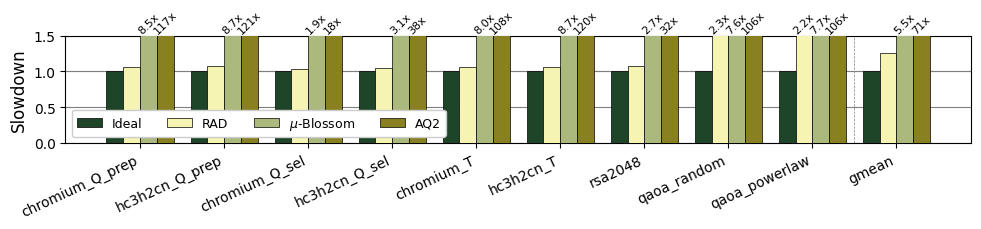

Saved rad_ipdc_slowdown.pdf


In [249]:
# Cell 1 — IPdC slowdown vs the ideal decoder: ideal, RAD, AQ2, MWPM (bar plot + PDF).
# slowdown = IPdC_ideal / IPdC_policy   (ideal == 1.0; higher is worse).
BENCH  = avail(ideal, rad, aq2, mwpm)
TICKS_ = ticks_for(BENCH)

# (policy dict, legend label, color). ideal is a flat 1.0 visual reference.
CONFIGS = [
    (ideal, 'Ideal', C1),
    (rad,   'RAD',   C2),
    (mwpm,  r'$\mu$-Blossom', C3),
    (aq2,   'AQ2',   C4),
]

YLIM = 1.5   # cap; bars beyond this are clipped and labeled with their factor.

fig, ax = plt.subplots(figsize=(10.0, 2.4))
n_groups = len(BENCH) + 1            # workloads + gmean
x = np.arange(n_groups)
n_cfg = len(CONFIGS)
width = 0.2

for i, (pol, label, color) in enumerate(CONFIGS):
    heights = slowdown(pol, BENCH) + [gmean_slowdown(pol, BENCH)]
    print(f'{label:>6}: gmean slowdown = {heights[-1]:7.2f}x')
    offset = (i - n_cfg / 2 + 0.5) * width
    ax.bar(x + offset, heights, width, label=label, color=color,
           edgecolor='black', linewidth=0.5, zorder=3)
    # Label bars that exceed the cap with their true slowdown factor.
    for xi, h in zip(x, heights):
        if h > YLIM:
            txt = f'{h:.0f}x' if h >= 10 else f'{h:.1f}x'
            ax.text(xi + offset, YLIM, txt, ha='center', va='bottom',
                    fontsize=8, rotation=45, color='black', zorder=5, clip_on=False)

ax.set_ylim(0, YLIM)
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--', zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(TICKS_ + ['gmean'], fontsize=10, rotation=25, ha='right')
ax.set_ylabel('Slowdown', fontsize=12)
ax.axvline(len(BENCH) - 0.5, color='gray', linewidth=0.5, linestyle='--')
ax.legend(fontsize=9, ncol=4, loc='lower left', framealpha=1.0)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', linestyle='-', color='gray', zorder=0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/rad_ipdc_slowdown.pdf', bbox_inches='tight')
plt.show()
print('Saved rad_ipdc_slowdown.pdf')

In [253]:
# Cell 2 — Full-program fidelity (vs the ideal decoder), printed tables.
# Fidelity of a run = P(no error in any cycle on any qubit AND no faulty T gate):
#     F = (1 - P_CYC)^(cycles * n_qubits) * (1 - P_T)^T_gates
# i.e. every one of a program's logical qubits independently risks a QEC
# failure each cycle, so the per-cycle term scales with qubit count.
# The sim only executes SIM_INST of each program's instructions, so scale the
# reported cycle / T-gate counts up to the FULL program:
#     scale = TOTAL_INST[b] / SIM_INST      (cycles, T_gates *= scale)
# Error rates are per benchmark; see DEFAULT_RATES / RATES below.
# Prints: relative fidelity F_policy / F_ideal (ratio -> gmean summary), absolute
# fidelity F_policy (probability -> arithmetic mean), and a LaTeX ABSOLUTE-fidelity
# table with columns µ-Blossom, AQ2, RAD, Ideal (in that order; Helios dropped).
DEFAULT_RATES = dict(cyc=1e-13, mwpm=1e-11, helios=1e-10, t=1e-12)
RATES = {
    'BQ_gidney25_rsa2048_256_of_20805': dict(cyc=1e-16, mwpm=1e-14, helios=1e-13, t=1e-12),
}

# Total instruction count of each *full* program (from the benchmarks table).
TOTAL_INST = {
    'BQ_bose_hubbard_q_prep': 188e6, 'BQ_bose_hubbard_q_sel': 19.6e6, 'BQ_bose_hubbard_t': 159e6,
    'BQ_chromium_q_prep':     337e6, 'BQ_chromium_q_sel':     216e6,  'BQ_chromium_t':     316e6,
    'BQ_hc3h2cn_q_prep':      332e6, 'BQ_hc3h2cn_q_sel':      411e6,  'BQ_hc3h2cn_t':      291e6,
    'BQ_gidney25_rsa2048_256_of_20805': 31.2e9,
    'BQ_qaoa_random':         336e6, 'BQ_qaoa_powerlaw':      264e6,
}

# Logical qubit count of each *full* program (from the benchmarks table).
QUBITS = {
    'BQ_bose_hubbard_q_prep': 2228, 'BQ_bose_hubbard_q_sel': 2228, 'BQ_bose_hubbard_t': 2188,
    'BQ_chromium_q_prep':     167,  'BQ_chromium_q_sel':     167,  'BQ_chromium_t':     121,
    'BQ_hc3h2cn_q_prep':      341,  'BQ_hc3h2cn_q_sel':      341,  'BQ_hc3h2cn_t':      289,
    'BQ_gidney25_rsa2048_256_of_20805': 1575,
    'BQ_qaoa_random':         2048, 'BQ_qaoa_powerlaw':      2048,
}

def logfid(s, p_cyc, p_t, total_inst, n_qubits):
    # log fidelity, scaled from the simulated window up to the full program.
    # Per-cycle term is multiplied by n_qubits: every logical qubit independently
    # risks a QEC failure each cycle.
    scale = total_inst / s['SIM_INST']
    return scale * (s['SIM_CYCLES'] * n_qubits * np.log(1-p_cyc)
                    + s['T_GATES_EXECUTED'] * np.log(1-p_t))

def fcell(v):   # fixed for readable magnitudes, scientific for the tiny ones
    return f'{v:>12.6f}'

def col_gmean(vals):   # geomean; returns 0 (no warning) if any value underflowed to 0
    a = np.asarray(vals, float)
    return 0.0 if np.any(a <= 0) else float(np.exp(np.mean(np.log(a))))

BENCH   = [b for b in avail(ideal, rad, aq2, mwpm) if b in TOTAL_INST and b in QUBITS]
skipped = [b for b in avail(ideal, rad, aq2, mwpm) if b not in TOTAL_INST or b not in QUBITS]
POLICIES = ('ideal', 'RAD', 'AQ2', 'MWPM', 'Helios')
DISP = {'MWPM': 'µ-Blossom'}   # display name (keys stay ASCII)

# Log fidelity of each policy per benchmark (Helios = ideal run at its own P_cyc;
# MWPM = mwpm_only run at its own, weaker, P_cyc).
rel = {p: [] for p in POLICIES}
absf = {p: [] for p in POLICIES}
for b in BENCH:
    tot = TOTAL_INST[b]
    nq  = QUBITS[b]
    r   = RATES.get(b, DEFAULT_RATES)
    lf = {
        'ideal':  logfid(ideal[b], r['cyc'],    r['t'], tot, nq),
        'RAD':    logfid(rad[b],   r['cyc'],    r['t'], tot, nq),
        'AQ2':    logfid(aq2[b],   r['cyc'],    r['t'], tot, nq),
        'MWPM':   logfid(mwpm[b],  r['mwpm'],   r['t'], tot, nq),
        'Helios': logfid(ideal[b], r['helios'], r['t'], tot, nq),
    }
    for p in POLICIES:
        rel[p].append(float(np.exp(lf[p] - lf['ideal'])))
        absf[p].append(float(np.exp(lf[p])))

def print_table(title, data, agg_fn, agg_label):
    print(title)
    print(f'{"workload":<20}' + ''.join(f'{DISP.get(p,p):>12}' for p in POLICIES))
    print('-' * (20 + 12 * len(POLICIES)))
    for i, b in enumerate(BENCH):
        print(f'{TMAP[b]:<20}' + ''.join(fcell(data[p][i]) for p in POLICIES))
    print('-' * (20 + 12 * len(POLICIES)))
    print(f'{agg_label:<20}' + ''.join(fcell(agg_fn(data[p])) for p in POLICIES))

def _grp(b):   # group rows in the LaTeX table: Q_prep+Q_sel | T | rsa2048+qaoa
    if b.endswith('_q_prep') or b.endswith('_q_sel'):
        return 0
    if b.endswith('_t'):
        return 1
    return 2

def latex_sci(v):
    # Scientific ($m \times 10^{e}$) for values >= 1e-4; anything smaller is
    # negligible and reported as ~0.
    if v < 1e-4:
        return r'$\sim 0$'
    return f'{v:.4f}'

def latex_fixed(v):   # 4 decimals -- for columns that stay close to 1 (Ideal, RAD)
    return f'{v:.4f}'

def print_latex_abs():
    # LaTeX ABSOLUTE-fidelity table (F_policy). Columns: MWPM, AQ2, RAD, Ideal.
    cols = [('MWPM',   r'$\mu$-Blossom', latex_sci),
            ('AQ2',    'AQ2',            latex_sci),
            ('RAD',    r'\impl',         latex_fixed),
            ('ideal',  'Ideal',          latex_fixed)]
    print('% ABSOLUTE fidelity (F_policy) -- paste into the paper')
    print(r'\hline')
    print(r'Benchmark & ' + ' & '.join(h for _, h, _ in cols) + r'\ \\')
    print(r'\hline')
    print(r'\hline')
    prev = _grp(BENCH[0])
    for i, b in enumerate(BENCH):
        g = _grp(b)
        if g != prev:
            print(r'\hline')
            prev = g
        name = TMAP[b].replace('_', r'\_')
        vals = ' & '.join(fmt(absf[p][i]) for p, _, fmt in cols)
        print(f'{name:<18} & {vals} \\\\')
    print(r'\hline')
    print(r'\hline')
    # Absolute fidelity is a probability -> arithmetic mean (matches the console table).
    mvals = ' & '.join(fmt(float(np.mean(absf[p]))) for p, _, fmt in cols)
    print(f'{"mean":<18} & {mvals} \\\\')
    print(r'\hline')

d = DEFAULT_RATES
print(f'Full-program fidelity  (default P_cyc={d["cyc"]:g}, MWPM={d["mwpm"]:g}, Helios={d["helios"]:g}, P_T={d["t"]:g})')
for b, r in RATES.items():
    print(f'  override {TMAP[b]}: P_cyc={r["cyc"]:g}, MWPM={r["mwpm"]:g}, Helios={r["helios"]:g}, P_T={r["t"]:g}')
if skipped:
    print('  (skipped, no TOTAL_INST/QUBITS entry: ' + ', '.join(TMAP[b] for b in skipped) + ')')
print()
# Relative fidelity is a ratio -> geomean; absolute is a probability -> arithmetic mean.
print_table('RELATIVE fidelity (F_policy / F_ideal):', rel, col_gmean, 'gmean')
print()
print_table('ABSOLUTE fidelity (F_policy):', absf, lambda v: float(np.mean(v)), 'mean')
print()
print_latex_abs()

Full-program fidelity  (default P_cyc=1e-13, MWPM=1e-11, Helios=1e-10, P_T=1e-12)
  override rsa2048: P_cyc=1e-16, MWPM=1e-14, Helios=1e-13, P_T=1e-12

RELATIVE fidelity (F_policy / F_ideal):
workload                   ideal         RAD         AQ2   µ-Blossom      Helios
--------------------------------------------------------------------------------
chromium_Q_prep         1.000000    0.990116    0.000000    0.000000    0.000000
hc3h2cn_Q_prep          1.000000    0.976533    0.000000    0.000000    0.000000
chromium_Q_sel          1.000000    0.996002    0.121945    0.000000    0.000000
hc3h2cn_Q_sel           1.000000    0.983767    0.000004    0.000000    0.000000
chromium_T              1.000000    0.992513    0.000001    0.000000    0.000000
hc3h2cn_T               1.000000    0.984054    0.000000    0.000000    0.000000
rsa2048                 1.000000    0.989327    0.010332    0.000000    0.000000
qaoa_random             1.000000    0.939045    0.005959    0.000000    0.00000

In [243]:
# Cell 3 — gmean IPdC slowdown for RAD across fast-decoder LER (print only).
# Uses a consistent benchmark set (present at every LER folder + ideal) so the
# points are directly comparable. Folders are globbed and sorted by LER value.
import glob
LER_FOLDERS = sorted((os.path.basename(p) for p in glob.glob(f'{STATS}/ler_sens_*')),
                     key=lambda f: float(f.rsplit('_', 1)[-1]))
ler = {f: aggregate_stats_by_policy(f'{STATS}/{f}') for f in LER_FOLDERS}

common = avail(ideal, *ler.values())
print(f'RAD IPdC slowdown vs fast-decoder LER  (consistent set of {len(common)} benchmarks)')
print(f'{"LER":>12}' + ''.join(f'{c:>9}' for c in CAT_LABELS))
print('-' * (12 + 9 * len(CAT_LABELS)))
for f in LER_FOLDERS:
    ler_val = f.rsplit('_', 1)[-1]
    print(f'{ler_val:>12}' + fmt_cat_row(cat_gmean_slowdowns(ler[f], common)))

RAD IPdC slowdown vs fast-decoder LER  (consistent set of 9 benchmarks)
         LER  Prepare   Select  Trotter      RSA     QAOA  Overall
------------------------------------------------------------------
       1e-08    1.01x    1.01x    1.01x    1.01x    1.62x    1.12x
     2.5e-08    1.02x    1.01x    1.02x    1.02x    1.76x    1.15x
       5e-08    1.04x    1.02x    1.03x    1.04x    1.91x    1.18x
     7.5e-08    1.05x    1.03x    1.04x    1.05x    2.09x    1.22x
     2.5e-07    1.18x    1.10x    1.16x    1.19x    3.76x    1.50x
       5e-07    1.40x    1.20x    1.36x    1.39x    5.03x    1.78x
     7.5e-07    1.76x    1.30x    1.69x    1.64x    9.62x    2.36x
       1e-06    2.09x    1.43x    2.14x    2.03x   19.20x    3.15x


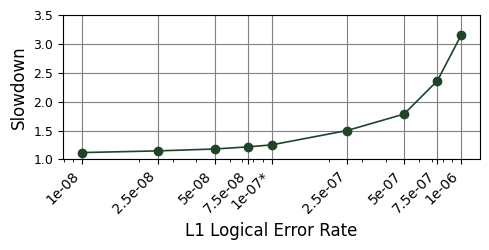

Saved rad_ler_sensitivity.pdf


In [224]:
# Cell 3b -- LER sensitivity plot: overall gmean IPdC slowdown vs L1 (fast-decoder) LER.
# Single-column plot. The default LER (1e-07, == base `rad`; there is no
# ler_sens_1e-07 folder) is included and its x-tick is marked with an asterisk.
LER_DEFAULT = 1e-7
ler_pts = [(float(f.rsplit('_', 1)[-1]), ler[f]) for f in LER_FOLDERS] + [(LER_DEFAULT, rad)]
ler_pts.sort(key=lambda r: r[0])

common_plot = avail(ideal, rad, *ler.values())
xs = [v for v, _ in ler_pts]
ys = [gmean_slowdown(pol, common_plot) for _, pol in ler_pts]
di = xs.index(LER_DEFAULT)

fig, ax = plt.subplots(figsize=(5.0, 2.6))
ax.plot(xs, ys, '-o', color=C1, linewidth=1.2, zorder=3, ms=6)
#ax.scatter([xs[di]], [ys[di]], color=C4, s=45, zorder=5)   # highlight the default

ax.set_xscale('log')
ax.set_xticks(xs)
ax.set_xticklabels([f'{v:g}' + ('*' if v == LER_DEFAULT else '') for v in xs],
                    fontsize=10, rotation=45, ha='right')
ax.set_xlabel('L1 Logical Error Rate', fontsize=12)
ax.set_ylabel('Slowdown', fontsize=12)
ax.tick_params(axis='y', labelsize=9)
ax.grid(True, which='major', axis='both', linestyle='-', color='gray', zorder=0)
ax.set_ylim(1.0, 3.5)

plt.tight_layout()
plt.savefig(f'{PLOTS}/rad_ler_sensitivity.pdf', bbox_inches='tight')
plt.show()
print('Saved rad_ler_sensitivity.pdf')


In [225]:
# Cell 4 — gmean IPdC slowdown for RAD across the L2 (AQ2) decoder latency.
# Same consistent-set treatment as Cell 3. Folders globbed and sorted by tr value.
TR_FOLDERS = sorted((os.path.basename(p) for p in glob.glob(f'{STATS}/tr_sens_*')),
                    key=lambda f: float(f.rsplit('_', 1)[-1]))
tr = {f: aggregate_stats_by_policy(f'{STATS}/{f}') for f in TR_FOLDERS}

# Relative-TR rows plus the 1x baseline (== base `rad`; there is no tr_sens_1.0).
TR_BASE_MS = 4.14   # base L2 (AQ2) decoder reaction latency, in ms
tr_rows = [(float(f.rsplit('_', 1)[-1]), tr[f]) for f in TR_FOLDERS] + [(1.0, rad)]
tr_rows.sort(key=lambda r: r[0])

common = avail(ideal, rad, *tr.values())
print(f'RAD IPdC slowdown vs L2 decoder latency  (consistent set of {len(common)} benchmarks)')
print(f'{"relTR":>12}' + ''.join(f'{c:>9}' for c in CAT_LABELS))
print('-' * (12 + 9 * len(CAT_LABELS)))
for rel, pol in tr_rows:
    print(f'{rel:>12.1f}' + fmt_cat_row(cat_gmean_slowdowns(pol, common)))

# LaTeX table: rows = workload categories (+ overall gmean bottom row);
# columns = the different L2 latencies (raw latency with its relative factor).
def _rel_str(r):
    return f'{r:g}'

def _lat_str(r):
    ms = r * TR_BASE_MS
    lat = rf'{ms * 1000:.0f}$\mu$s' if ms < 1 else f'{ms:.2f}ms'
    return rf'{lat} (${_rel_str(r)}\times$)'

col_vals = {rel: cat_gmean_slowdowns(pol, common) for rel, pol in tr_rows}
row_spec = [(name, i) for i, (name, _) in enumerate(CATEGORIES)] + [('gmean', len(CATEGORIES))]
print('\n% L2-latency (TR) sensitivity: gmean IPdC slowdown -- paste into the paper')
print(r'\hline')
print(r' & \multicolumn{%d}{c}{L2 Latency} \\' % len(tr_rows))
print('Workload & ' + ' & '.join(_lat_str(rel) for rel, _ in tr_rows) + r' \\')
print(r'\hline')
print(r'\hline')
for name, i in row_spec:
    if name == 'gmean':
        print(r'\hline')
    vals = ' & '.join(f'{col_vals[rel][i]:.2f}' if col_vals[rel][i] == col_vals[rel][i] else '-'
                      for rel, _ in tr_rows)
    print(f'{name:<8} & {vals} \\\\')
print(r'\hline')


RAD IPdC slowdown vs L2 decoder latency  (consistent set of 9 benchmarks)
       relTR  Prepare   Select  Trotter      RSA     QAOA  Overall
------------------------------------------------------------------
         0.1    1.00x    1.00x    1.00x    1.00x    1.07x    1.02x
         0.5    1.02x    1.01x    1.02x    1.02x    1.69x    1.14x
         1.0    1.07x    1.04x    1.06x    1.07x    2.26x    1.25x
         1.5    1.18x    1.07x    1.15x    1.13x    2.98x    1.41x
         2.0    1.38x    1.13x    1.29x    1.20x    3.57x    1.58x

% L2-latency (TR) sensitivity: gmean IPdC slowdown -- paste into the paper
\hline
 & \multicolumn{5}{c}{L2 Latency} \\
Workload & 414$\mu$s ($0.1\times$) & 2.07ms ($0.5\times$) & 4.14ms ($1\times$) & 6.21ms ($1.5\times$) & 8.28ms ($2\times$) \\
\hline
\hline
Prepare  & 1.00 & 1.02 & 1.07 & 1.18 & 1.38 \\
Select   & 1.00 & 1.01 & 1.04 & 1.07 & 1.13 \\
Trotter  & 1.00 & 1.02 & 1.06 & 1.15 & 1.29 \\
RSA      & 1.00 & 1.02 & 1.07 & 1.13 & 1.20 \\
QAOA     

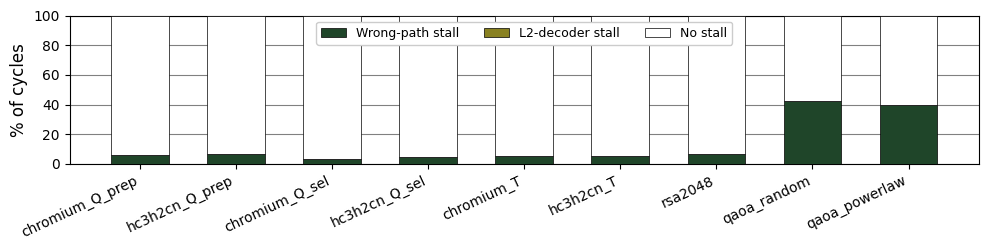

Saved rad_cycle_stall_breakdown.pdf

Stall cycles (% of SIM_CYCLES):
  chromium_Q_prep        5.79%
  hc3h2cn_Q_prep         6.78%
  chromium_Q_sel         3.18%
  hc3h2cn_Q_sel          4.58%
  chromium_T             5.52%
  hc3h2cn_T              5.49%
  rsa2048                6.63%
  qaoa_random           42.45%
  qaoa_powerlaw         39.56%
  mean (arith)          13.33%

% Stall-cycle percentage (% of SIM_CYCLES) -- paste into the paper
\hline
Benchmark & Percentage of Cycles Stalled \\
\hline
\hline
chromium\_Q\_prep    & 5.79\% \\
hc3h2cn\_Q\_prep     & 6.78\% \\
chromium\_Q\_sel     & 3.18\% \\
hc3h2cn\_Q\_sel      & 4.58\% \\
\hline
chromium\_T          & 5.52\% \\
hc3h2cn\_T           & 5.49\% \\
\hline
rsa2048              & 6.63\% \\
qaoa\_random         & 42.45\% \\
qaoa\_powerlaw       & 39.56\% \\
\hline
\hline
mean                 & 13.33 \\
\hline


In [230]:
# Cell 5 — RAD cycle-stall breakdown: stacked % of SIM_CYCLES per workload.
# Three segments per workload (sum to 100%):
#   (1) wrong-path-execution stalls, EXCLUDING cycles locked to the L2 decoder.
#       L2 locking only happens while stalled on a wrong path, so those cycles
#       are a subset of the wrong-path stall cycles -- we peel them out here.
#   (2) cycles forced onto the slow L2 decoder.
#   (3) no-stall cycles (the remainder) -- drawn as a white bar.
# Wrong-path stall cycles are derived from the WRONG_PATH_LATENCY histogram
# rather than the FR_CYCLES_STALLED_BY_WRONG_PATH stat: total stall cycles =
# WRONG_PATHS_DURING_EXECUTION * mean(WRONG_PATH_LATENCY).
WP_COUNT_KEY = 'WRONG_PATHS_DURING_EXECUTION'
WP_LAT_KEY   = 'WRONG_PATH_LATENCY'          # nested histogram; use its MEAN
CYC_KEY      = 'SIM_CYCLES'
L2_KEY       = 'FR_CYCLES_LOCKED_TO_L2_DECODER'    # subset locked to the L2 decoder

BENCH  = [b for b in BENCHMARKS
          if WP_COUNT_KEY in rad.get(b, {}) and WP_LAT_KEY in rad.get(b, {})
          and L2_KEY in rad.get(b, {})]
TICKS_ = ticks_for(BENCH)

wp_total = np.array([rad[b][WP_COUNT_KEY] * rad[b][WP_LAT_KEY]['MEAN'] / rad[b][CYC_KEY]
                      for b in BENCH]) * 100.0                                # total wrong-path %
l2       = np.array([rad[b][L2_KEY]                  for b in BENCH]) * 100.0  # (2)
wp_only  = wp_total - l2                                                       # (1)
nostall  = 100.0 - wp_total                                                    # (3)

# (heights, legend label, color). Stacked bottom -> top; no-stall is white.
SEGS = [
    (wp_only, 'Wrong-path stall', C1),
    (l2,      'L2-decoder stall', C4),
    (nostall, 'No stall',         'white'),
]

x = np.arange(len(BENCH))
fig, ax = plt.subplots(figsize=(10.0, 2.6))
bottom = np.zeros(len(BENCH))
for heights, label, color in SEGS:
    ax.bar(x, heights, 0.6, bottom=bottom, label=label, color=color,
           edgecolor='black', linewidth=0.5, zorder=3)
    bottom = bottom + heights

ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(TICKS_, fontsize=10, rotation=25, ha='right')
ax.set_ylabel('% of cycles', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=9, ncol=3, loc='upper center', framealpha=1.0)
ax.grid(axis='y', linestyle='-', color='gray', zorder=0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/rad_cycle_stall_breakdown.pdf', bbox_inches='tight')
plt.show()

print('Saved rad_cycle_stall_breakdown.pdf')

# Total stall cycles per workload = wrong-path + L2 (L2 is a subset of wrong path,
# so this equals wp_total). Reported as a % of SIM_CYCLES.
stall = wp_only + l2
print('\nStall cycles (% of SIM_CYCLES):')
for b, s in zip(BENCH, stall):
    print(f'  {TMAP[b]:<20} {s:6.2f}%')
print(f'  {"mean (arith)":<20} {np.mean(stall):6.2f}%')

# LaTeX table -- arithmetic mean. Grouped Q_prep/Q_sel | T | rsa2048/qaoa.
def _grp(b):
    if b.endswith('_q_prep') or b.endswith('_q_sel'): return 0
    if b.endswith('_t'): return 1
    return 2
print('\n% Stall-cycle percentage (% of SIM_CYCLES) -- paste into the paper')
print(r'\hline')
print(r'Benchmark & Percentage of Cycles Stalled \\')
print(r'\hline')
print(r'\hline')
prev = _grp(BENCH[0])
for b, s in zip(BENCH, stall):
    g = _grp(b)
    if g != prev:
        print(r'\hline'); prev = g
    name = TMAP[b].replace('_', r'\_')
    print(f'{name:<20} & {s:.2f}\% \\\\')
print(r'\hline')
print(r'\hline')
print(f'{"mean":<20} & {np.mean(stall):.2f} \\\\')
print(r'\hline')


In [227]:
# Cell 6 -- RAD gmean IPdC slowdown and BRAM utilization vs R-FIFO capacity.
# Only the overall gmean slowdown is reported (no per-category breakdown).
# BRAM utilization comes from post-synthesis resource reports (not the sim
# stats dumps) for R-FIFO depths of 512/1K/2K/4K(base)/8K/16K entries.
RFIFO_BASE = 4096   # base R-FIFO capacity, in entries (== base `rad`)
RFIFO_FOLDERS = sorted((os.path.basename(p) for p in glob.glob(f'{STATS}/rfifo_sens_*')
                        if os.path.basename(p).rsplit('_', 1)[-1].isdigit()),
                       key=lambda f: int(f.rsplit('_', 1)[-1]))
rfifo = {f: aggregate_stats_by_policy(f'{STATS}/{f}') for f in RFIFO_FOLDERS}

rfifo_rows = [(int(f.rsplit('_', 1)[-1]), rfifo[f]) for f in RFIFO_FOLDERS] + [(RFIFO_BASE, rad)]
rfifo_rows.sort(key=lambda r: r[0])

# BRAM utilization (post-synthesis), keyed by R-FIFO depth in entries.
RFIFO_BRAM_PCT = {512: 1.39, 1024: 2.08, 2048: 3.47, 4096: 6.25, 8192: 12.50, 16384: 25.00}

def _bram_str(depth, pct_fmt='{:.2f}%'):
    pct = RFIFO_BRAM_PCT.get(depth)
    return pct_fmt.format(pct) if pct is not None else 'TBD'

common = avail(ideal, rad, *rfifo.values())
print(f'RAD IPdC slowdown vs R-FIFO capacity  (consistent set of {len(common)} benchmarks)')
print(f'{"depth":>8}{"gmean":>10}{"BRAM %":>10}')
print('-' * 28)
for depth, pol in rfifo_rows:
    g = gmean_slowdown(pol, common)
    print(f'{depth:>8}{g:>9.2f}x{_bram_str(depth):>10}')

# LaTeX table: one row per R-FIFO capacity; columns = gmean slowdown & BRAM utilization.
def _depth_str(d):
    return f'{d // 1024}K' if d % 1024 == 0 else str(d)

print()
print(r'% R-FIFO capacity sensitivity: gmean IPdC slowdown + BRAM utilization -- paste into the paper')
print(r'\hline')
print(r'R-FIFO Capacity & Gmean Slowdown & BRAM Util. (\%) \\')
print(r'\hline')
print(r'\hline')
for depth, pol in rfifo_rows:
    g = gmean_slowdown(pol, common)
    label = _depth_str(depth) + (' (base)' if depth == RFIFO_BASE else '')
    print(rf'{label} & {g:.2f}$\times$ & {_bram_str(depth, "{:.2f}")} \\')
print(r'\hline')


RAD IPdC slowdown vs R-FIFO capacity  (consistent set of 9 benchmarks)
   depth     gmean    BRAM %
----------------------------
     512     1.75x     1.39%
    1024     1.53x     2.08%
    2048     1.34x     3.47%
    4096     1.25x     6.25%
    8192     1.27x    12.50%
   16384     1.28x    25.00%

% R-FIFO capacity sensitivity: gmean IPdC slowdown + BRAM utilization -- paste into the paper
\hline
R-FIFO Capacity & Gmean Slowdown & BRAM Util. (\%) \\
\hline
\hline
512 & 1.75$\times$ & 1.39 \\
1K & 1.53$\times$ & 2.08 \\
2K & 1.34$\times$ & 3.47 \\
4K (base) & 1.25$\times$ & 6.25 \\
8K & 1.27$\times$ & 12.50 \\
16K & 1.28$\times$ & 25.00 \\
\hline


RAD gmean IPdC slowdown vs R-FIFO capacity  (consistent set of 9 benchmarks)
   depth    LER=1e-7    LER=1e-8
--------------------------------
     512       1.75x       1.67x
      1K       1.53x       1.46x
      2K       1.34x       1.27x
      4K       1.25x       1.12x
      8K       1.27x       1.07x
     16K       1.28x       1.07x


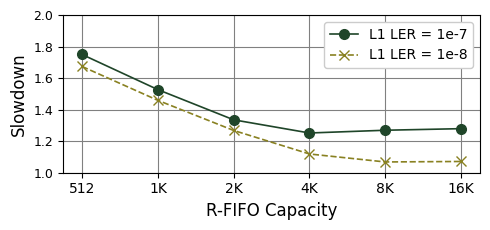

Saved rad_rfifo_ler_sensitivity.pdf


In [228]:
# Cell 7 -- RAD gmean IPdC slowdown vs R-FIFO capacity, at two L1 (fast-decoder)
# LER settings: the default 1e-7 and a lower 1e-8. Reuses the depth->folder
# convention of Cell 6, plus the *_p1e-07 / *_p1e-08 combined rfifo x LER sweep
# folders. The depth=4096 point for each curve is the existing single-axis
# sweep at that LER: `rad` for 1e-7 (base config) and `ler_sens_1e-08` for 1e-8.
RFIFO_LER_DEPTHS = [512, 1024, 2048, 8192, 16384]
rfifo_p7 = {d: aggregate_stats_by_policy(f'{STATS}/rfifo_sens_{d}_p1e-07') for d in RFIFO_LER_DEPTHS}
rfifo_p8 = {d: aggregate_stats_by_policy(f'{STATS}/rfifo_sens_{d}_p1e-08') for d in RFIFO_LER_DEPTHS}
ler8 = aggregate_stats_by_policy(f'{STATS}/ler_sens_1e-08')

curve_1e7 = {**rfifo_p7, RFIFO_BASE: rad}
curve_1e8 = {**rfifo_p8, RFIFO_BASE: ler8}

common = avail(ideal, *curve_1e7.values(), *curve_1e8.values())
depths = sorted(curve_1e7)   # == sorted(curve_1e8)
ys_1e7 = [gmean_slowdown(curve_1e7[d], common) for d in depths]
ys_1e8 = [gmean_slowdown(curve_1e8[d], common) for d in depths]

print(f'RAD gmean IPdC slowdown vs R-FIFO capacity  (consistent set of {len(common)} benchmarks)')
print(f'{"depth":>8}{"LER=1e-7":>12}{"LER=1e-8":>12}')
print('-' * 32)
for d, y7, y8 in zip(depths, ys_1e7, ys_1e8):
    print(f'{_depth_str(d):>8}{y7:>11.2f}x{y8:>11.2f}x')

fig, ax = plt.subplots(figsize=(5.0, 2.4))
ax.plot(depths, ys_1e7, 'o-', markersize=7, color=C1, linewidth=1.2,
        label='L1 LER = 1e-7', zorder=3)
ax.plot(depths, ys_1e8, 'x--', markersize=7, color=C4, linewidth=1.2,
        label='L1 LER = 1e-8', zorder=3)

ax.set_xscale('log', base=2)
ax.set_xticks(depths)
ax.set_xticklabels([_depth_str(d) for d in depths], fontsize=10)
ax.set_xlabel('R-FIFO Capacity', fontsize=12)
ax.set_ylabel('Slowdown', fontsize=12)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=10, framealpha=1.0)
ax.grid(True, which='major', axis='both', linestyle='-', color='gray', zorder=0)
ax.set_ylim(1.0, 2.0)

plt.tight_layout()
plt.savefig(f'{PLOTS}/rad_rfifo_ler_sensitivity.pdf', bbox_inches='tight')
plt.show()
print('Saved rad_rfifo_ler_sensitivity.pdf')


In [229]:
# Cell 8 -- RAD wrong-path recovery rate per program: WRONG_PATHS_DURING_EXECUTION
# divided by SIM_CYCLES. Reported per million cycles for readability (raw rates
# are ~1e-6 to ~1e-4 per cycle).
WP_COUNT_KEY = 'WRONG_PATHS_DURING_EXECUTION'
CYC_KEY = 'SIM_CYCLES'

BENCH = [b for b in BENCHMARKS if WP_COUNT_KEY in rad.get(b, {}) and CYC_KEY in rad.get(b, {})]
wp_rate = {b: rad[b][WP_COUNT_KEY] / rad[b][CYC_KEY] * 1e6 for b in BENCH}

print('RAD wrong-path recovery rate (wrong paths per 1e6 SIM_CYCLES)')
print(f'{"workload":<20}{"wrong paths":>14}{"SIM_CYCLES":>14}{"rate/1e6cyc":>14}')
print('-' * 62)
for b in BENCH:
    print(f'{TMAP[b]:<20}{rad[b][WP_COUNT_KEY]:>14}{rad[b][CYC_KEY]:>14}{wp_rate[b]:>13.2f}')


RAD wrong-path recovery rate (wrong paths per 1e6 SIM_CYCLES)
workload               wrong paths    SIM_CYCLES   rate/1e6cyc
--------------------------------------------------------------
chromium_Q_prep                190      30483074         6.23
hc3h2cn_Q_prep                 231      30979253         7.46
chromium_Q_sel                 169      34860778         4.85
hc3h2cn_Q_sel                  156      25482767         6.12
chromium_T                     218      35574650         6.13
hc3h2cn_T                      212      34852358         6.08
rsa2048                        272      28849328         9.43
qaoa_random                    162       1625684        99.65
qaoa_powerlaw                  162       1555502       104.15
